# 03 — Baselines y refinamiento

Este notebook ejecuta y compara los baselines de Sprint 3 usando exclusivamente:

- `partition == development`;
- folds persistidos en `splits.parquet`;
- una implementación común de métricas y cross-validation;
- pipelines que ajustan todo preprocesamiento dentro de outer train.

Los test finales no se cargan ni se utilizan.

La presentación prioriza gráficos y diagnósticos por clase. Los resultados completos por fold se conservan en:

```text
reports/cv_results.csv
reports/feature_selection.csv
```

Las matrices de confusión se construyen con predicciones *out-of-fold* concatenadas y se normalizan por clase verdadera.

## 1. Configuración y carga de artefactos

In [18]:
import sys
from functools import partial
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

from src.evaluation.reporting import (
    save_cv_results,
    save_feature_selection,
    summarize_cv_results,
    upsert_cv_results,
    upsert_feature_selection,
)
from src.experiments.baselines import make_model_factory, run_baseline_grid
from src.experiments.cross_validation import run_cv
from src.experiments.representation_refinement import (
    run_feature_importance_grid,
    run_pca_grid,
    run_rfecv_grid,
)
from src.feature_selection import (
    build_pca_linear_probe,
    get_pca_fold_metadata,
    run_nested_rfecv,
)
from src.feature_selection.importance import summarize_feature_importance
from src.features.feature_store import load_representation
from src.utils.config import get_config, resolve_path
from src.utils.io import load_metadata, load_splits
from src.utils.reproducibility import set_global_seed

cfg = get_config()
set_global_seed(cfg.seed)

metadata = load_metadata(cfg.paths.metadata)
splits = load_splits(cfg.paths.splits)
representations = {
    "egemaps": load_representation("egemaps", cfg.paths.features_dir),
    "wav2vec": load_representation("wav2vec", cfg.paths.features_dir),
}

print(f"Metadata: {metadata.shape}")
print(f"Splits: {splits.shape}")
for name, frame in representations.items():
    print(f"{name}: {frame.shape}")

2026-06-23 13:35:02 | INFO     | src.features.feature_store | Cargado 'egemaps': 1440 muestras, 88 features.


2026-06-23 13:35:02 | INFO     | src.features.feature_store | Cargado 'wav2vec': 1440 muestras, 768 features.
Metadata: (1440, 23)
Splits: (1440, 4)
egemaps: (1440, 89)
wav2vec: (1440, 769)


## 2. Funciones de visualización

In [19]:
EXPERIMENT_COLUMNS = [
    "representation",
    "protocol",
    "target",
    "model",
    "refinement",
]

TARGET_LABELS = {
    "emotion_original": "8 emociones",
    "emotion_quadrant": "4 cuadrantes directos",
    "emotion_original_eval_quadrant": "8→4 cuadrantes",
}

PROTOCOL_LABELS = {
    "speaker_dependent": "Speaker-dependent",
    "speaker_independent": "Speaker-independent",
}


def configuration_label(row):
    refinement = str(row["refinement"])
    suffix = "" if refinement == "none" else f" · {refinement}"
    return f"{row['representation']} · {row['model']}{suffix}"


def plot_top_configurations(summary, protocol="speaker_independent", top_n=8):
    data = summary.query("protocol == @protocol").copy()
    if data.empty:
        print("No hay resultados para graficar.")
        return

    targets = [target for target in TARGET_LABELS if target in set(data["target"])]
    fig, axes = plt.subplots(
        1,
        len(targets),
        figsize=(7 * len(targets), max(5, top_n * 0.48)),
        squeeze=False,
    )

    for ax, target in zip(axes.ravel(), targets):
        target_data = (
            data.query("target == @target")
            .sort_values(
                ["macro_f1_mean", "macro_f1_std"],
                ascending=[False, True],
            )
            .head(top_n)
            .copy()
        )
        target_data["configuration"] = target_data.apply(
            configuration_label,
            axis=1,
        )
        target_data = target_data.sort_values("macro_f1_mean")

        ax.errorbar(
            target_data["macro_f1_mean"],
            target_data["configuration"],
            xerr=target_data["macro_f1_std"],
            fmt="o",
            capsize=3,
        )
        ax.set_title(TARGET_LABELS[target])
        ax.set_xlabel("Macro F1 medio ± desvío")
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle(
        f"Mejores configuraciones — {PROTOCOL_LABELS.get(protocol, protocol)}",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


def plot_protocol_scatter(summary):
    data = summary.pivot_table(
        index=["representation", "target", "model", "refinement"],
        columns="protocol",
        values="macro_f1_mean",
    ).reset_index()

    required = {"speaker_dependent", "speaker_independent"}
    if not required.issubset(data.columns):
        print("Faltan resultados de alguno de los protocolos.")
        return

    targets = [target for target in TARGET_LABELS if target in set(data["target"])]
    fig, axes = plt.subplots(
        1,
        len(targets),
        figsize=(6 * len(targets), 5),
        squeeze=False,
    )

    for ax, target in zip(axes.ravel(), targets):
        target_data = data.query("target == @target").copy()
        ax.scatter(
            target_data["speaker_independent"],
            target_data["speaker_dependent"],
            alpha=0.8,
        )

        lower = float(
            min(
                target_data["speaker_independent"].min(),
                target_data["speaker_dependent"].min(),
            )
        )
        upper = float(
            max(
                target_data["speaker_independent"].max(),
                target_data["speaker_dependent"].max(),
            )
        )
        margin = max(0.02, (upper - lower) * 0.08)
        ax.plot(
            [lower - margin, upper + margin],
            [lower - margin, upper + margin],
            linestyle="--",
            linewidth=1,
        )
        ax.set_xlim(lower - margin, upper + margin)
        ax.set_ylim(lower - margin, upper + margin)
        ax.set_xlabel("Macro F1 speaker-independent")
        ax.set_ylabel("Macro F1 speaker-dependent")
        ax.set_title(TARGET_LABELS[target])
        ax.grid(alpha=0.2)

    fig.suptitle(
        "Brecha de generalización entre protocolos\n"
        "Los puntos sobre la diagonal rinden mejor con hablantes conocidos",
        y=1.05,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


def plot_8_to_4_tradeoff(cv_results):
    required = {"original_macro_f1", "macro_f1"}
    if cv_results.empty or not required.issubset(cv_results.columns):
        print("No hay métricas 8→4 disponibles.")
        return

    data = (
        cv_results
        .query("target == 'emotion_original_eval_quadrant'")
        .groupby(
            ["representation", "protocol", "model", "refinement"],
            observed=True,
        )
        .agg(
            original_macro_f1=("original_macro_f1", "mean"),
            quadrant_macro_f1=("macro_f1", "mean"),
        )
        .reset_index()
    )

    if data.empty:
        print("No hay resultados 8→4 disponibles.")
        return

    fig, ax = plt.subplots(figsize=(8, 6))
    for protocol, group in data.groupby("protocol", observed=True):
        ax.scatter(
            group["original_macro_f1"],
            group["quadrant_macro_f1"],
            label=PROTOCOL_LABELS.get(protocol, protocol),
            alpha=0.85,
        )

    ax.set_xlabel("Macro F1 original — 8 emociones")
    ax.set_ylabel("Macro F1 después del colapso — 4 cuadrantes")
    ax.set_title("Efecto del colapso 8→4")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_normalized_confusion(
    predictions,
    title,
    labels=None,
    ax=None,
):
    if predictions.empty:
        raise ValueError("No hay predicciones para la matriz de confusión.")

    use_eval_space = {
        "y_true_eval",
        "y_pred_eval",
    }.issubset(predictions.columns) and predictions["y_true_eval"].notna().any()

    true_col = "y_true_eval" if use_eval_space else "y_true"
    pred_col = "y_pred_eval" if use_eval_space else "y_pred"

    y_true = predictions[true_col].astype(str)
    y_pred = predictions[pred_col].astype(str)

    resolved_labels = (
        list(labels)
        if labels is not None
        else sorted(set(y_true) | set(y_pred))
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=resolved_labels,
        normalize="true",
    )

    if ax is None:
        _, ax = plt.subplots(
            figsize=(max(5, len(resolved_labels) * 0.8), max(4, len(resolved_labels) * 0.7))
        )

    image = ax.imshow(matrix, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(resolved_labels)))
    ax.set_yticks(range(len(resolved_labels)))
    ax.set_xticklabels(resolved_labels, rotation=45, ha="right")
    ax.set_yticklabels(resolved_labels)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Clase verdadera")
    ax.set_title(title)

    threshold = 0.5
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix[row_idx, col_idx]
            ax.text(
                col_idx,
                row_idx,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontsize=8,
            )

    return image, matrix, resolved_labels


def plot_confusion_delta(
    baseline_predictions,
    refined_predictions,
    title,
    labels=None,
    ax=None,
):
    use_eval_space = (
        {"y_true_eval", "y_pred_eval"}.issubset(baseline_predictions.columns)
        and baseline_predictions["y_true_eval"].notna().any()
    )
    true_col = "y_true_eval" if use_eval_space else "y_true"
    pred_col = "y_pred_eval" if use_eval_space else "y_pred"

    if labels is None:
        labels = sorted(
            set(baseline_predictions[true_col].astype(str))
            | set(baseline_predictions[pred_col].astype(str))
            | set(refined_predictions[true_col].astype(str))
            | set(refined_predictions[pred_col].astype(str))
        )

    base_matrix = confusion_matrix(
        baseline_predictions[true_col].astype(str),
        baseline_predictions[pred_col].astype(str),
        labels=labels,
        normalize="true",
    )
    refined_matrix = confusion_matrix(
        refined_predictions[true_col].astype(str),
        refined_predictions[pred_col].astype(str),
        labels=labels,
        normalize="true",
    )
    delta = refined_matrix - base_matrix

    if ax is None:
        _, ax = plt.subplots(figsize=(max(5, len(labels) * 0.8), max(4, len(labels) * 0.7)))

    limit = max(0.05, float(np.abs(delta).max()))
    image = ax.imshow(delta, vmin=-limit, vmax=limit, aspect="auto", cmap="coolwarm")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Clase verdadera")
    ax.set_title(title)

    for row_idx in range(delta.shape[0]):
        for col_idx in range(delta.shape[1]):
            ax.text(
                col_idx,
                row_idx,
                f"{delta[row_idx, col_idx]:+.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    return image, delta

## 3. Validación visual de development y folds

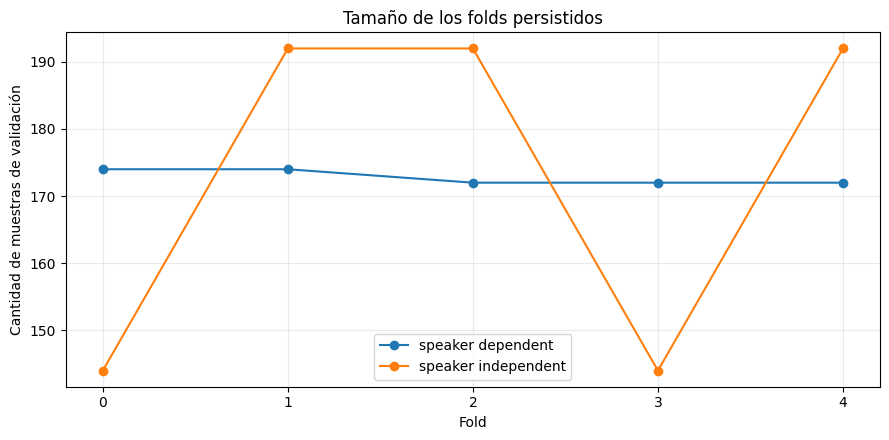

In [20]:
development = metadata.merge(
    splits,
    on="file_id",
    how="inner",
    validate="one_to_one",
).query("partition == 'development'")

assert len(development) == 864
assert (
    development[["fold_speaker_dependent", "fold_speaker_independent"]] >= 0
).all().all()
assert development["emotion_original"].nunique() == 8
assert development["emotion_quadrant"].nunique() == 4

fold_audit = (
    development
    .melt(
        value_vars=[
            "fold_speaker_dependent",
            "fold_speaker_independent",
        ],
        var_name="protocol",
        value_name="fold",
    )
    .groupby(["protocol", "fold"], observed=True)
    .size()
    .rename("n_samples")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for protocol, group in fold_audit.groupby("protocol", observed=True):
    ax.plot(
        group["fold"],
        group["n_samples"],
        marker="o",
        label=protocol.replace("fold_", "").replace("_", " "),
    )

ax.set_xticks(sorted(fold_audit["fold"].unique()))
ax.set_xlabel("Fold")
ax.set_ylabel("Cantidad de muestras de validación")
ax.set_title("Tamaño de los folds persistidos")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Configuración de ejecución

Los bloques pueden ejecutarse de forma independiente. Para analizar resultados ya calculados, mantener los flags en `False`.

La matriz completa de baselines contiene:

```text
2 representaciones × 2 protocolos × 3 targets × 3 modelos × 5 folds
```

In [21]:
RUN_BASELINES = False
RUN_FEATURE_IMPORTANCE = False
RUN_RFECV = False
RUN_PCA = False

REPRESENTATIONS = ["egemaps", "wav2vec"]
PROTOCOLS = ["speaker_dependent", "speaker_independent"]
TARGETS = [
    "emotion_original",
    "emotion_quadrant",
    "emotion_original_eval_quadrant",
]
MODELS = [
    "random_forest",
    "logistic_regression",
    "mlp",
]

cv_results_path = resolve_path("reports/cv_results.csv")
feature_selection_path = resolve_path("reports/feature_selection.csv")

if RUN_BASELINES:
    baseline_output = run_baseline_grid(
        representations=representations,
        metadata=metadata,
        splits=splits,
        model_configs=cfg.models,
        seed=cfg.seed,
        representation_names=REPRESENTATIONS,
        protocols=PROTOCOLS,
        targets=TARGETS,
        models=MODELS,
        n_folds=cfg.splits.cv_folds,
    )
    cv_results = baseline_output["fold_results"]
    save_cv_results(cv_results, cv_results_path)
    print(f"Resultados baseline guardados en {cv_results_path}")
elif cv_results_path.exists():
    cv_results = pd.read_csv(cv_results_path)
    print(f"Resultados cargados desde {cv_results_path}")
else:
    cv_results = pd.DataFrame()
    print("No existe reports/cv_results.csv. Activar RUN_BASELINES para generarlo.")

feature_selection = (
    pd.read_csv(feature_selection_path)
    if feature_selection_path.exists()
    else pd.DataFrame()
)

Resultados cargados desde /home/ale/Downloads/Speech_Emotion_Recognition/reports/cv_results.csv


## 5. Panorama visual de resultados

66 configuraciones consolidadas · 330 resultados por fold


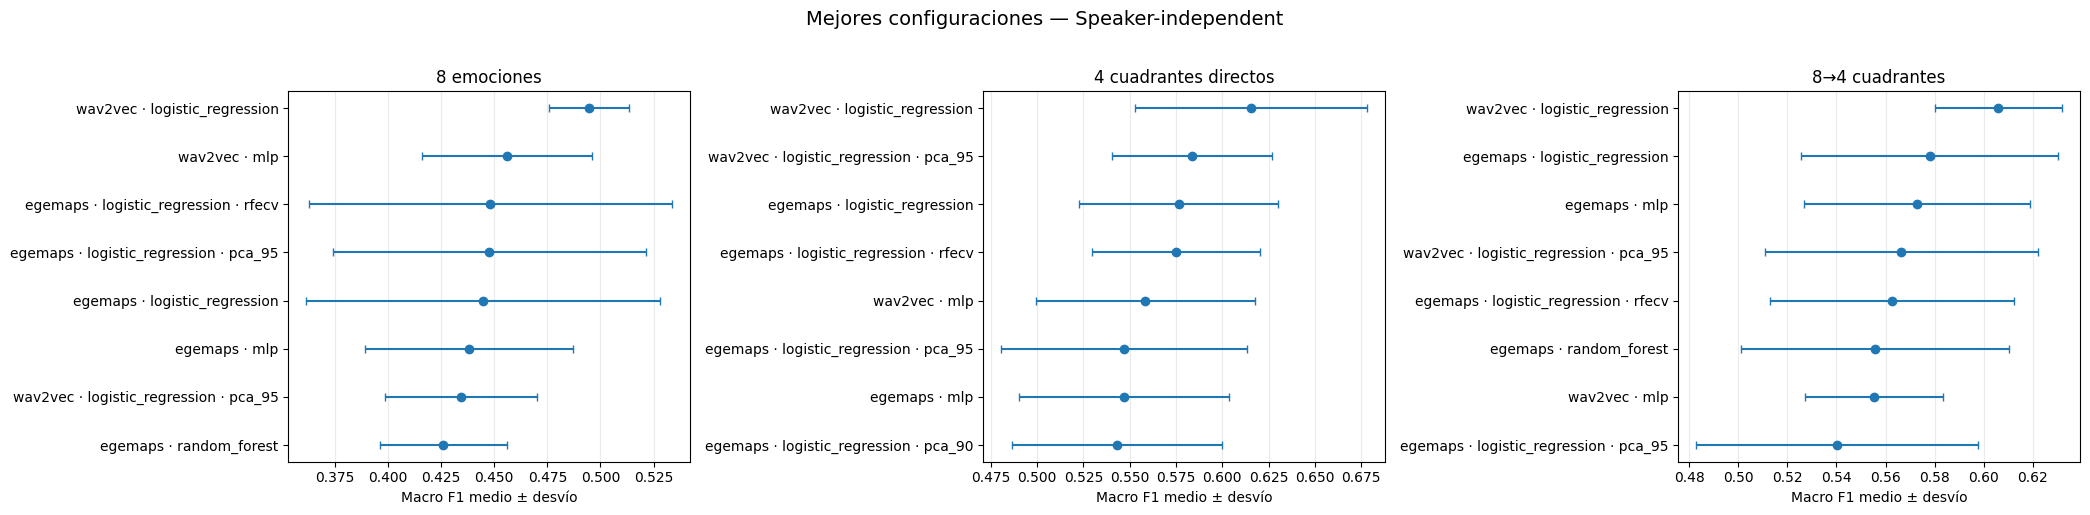

In [22]:
if cv_results.empty:
    summary = pd.DataFrame()
    print("Sin resultados consolidados.")
else:
    summary = summarize_cv_results(cv_results)
    print(
        f"{len(summary)} configuraciones consolidadas · "
        f"{len(cv_results)} resultados por fold"
    )
    plot_top_configurations(
        summary,
        protocol="speaker_independent",
        top_n=8,
    )

### Lectura

- El punto representa el macro F1 medio.
- La barra horizontal representa el desvío entre folds.
- Configuraciones cercanas deben interpretarse junto con su estabilidad y complejidad.

## 6. Brecha entre speaker-dependent y speaker-independent

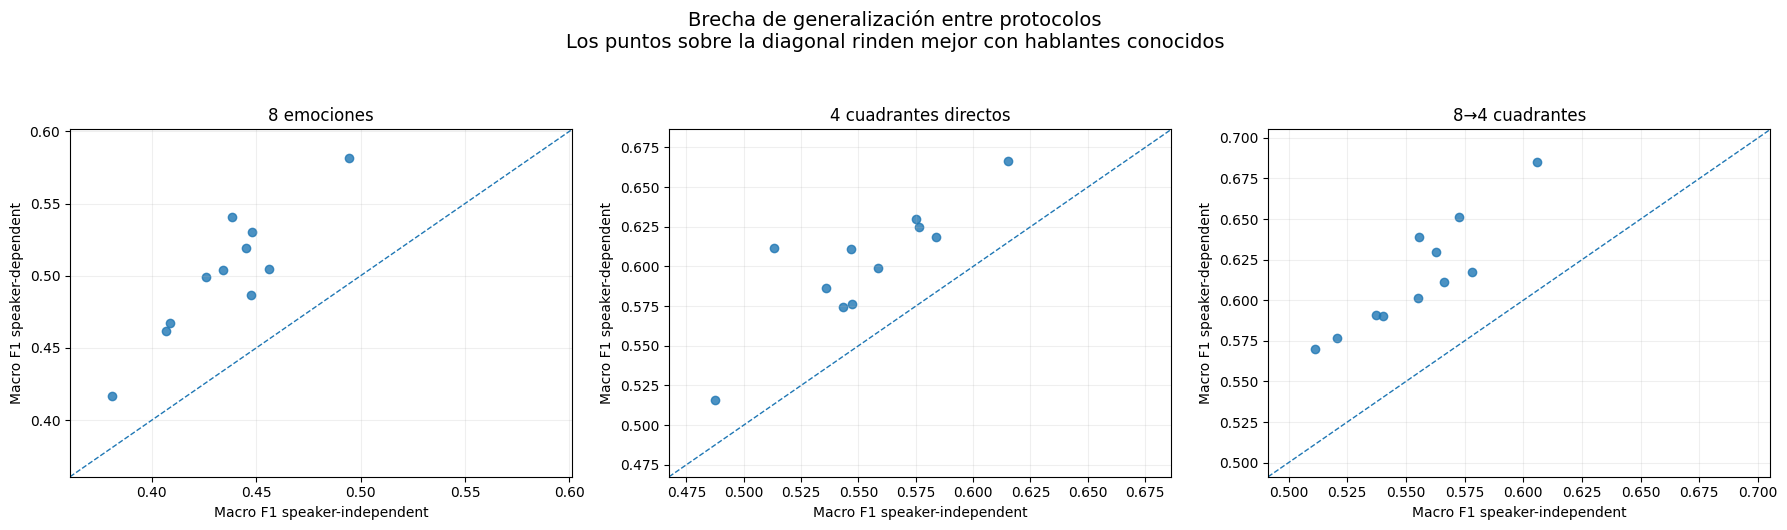

In [23]:
if not summary.empty:
    plot_protocol_scatter(summary)

Los puntos alejados por encima de la diagonal indican una fuerte ventaja cuando los actores son conocidos. Esa brecha es evidencia de dependencia respecto de identidad vocal o características particulares del hablante.

## 7. Lectura visual del target 8→4

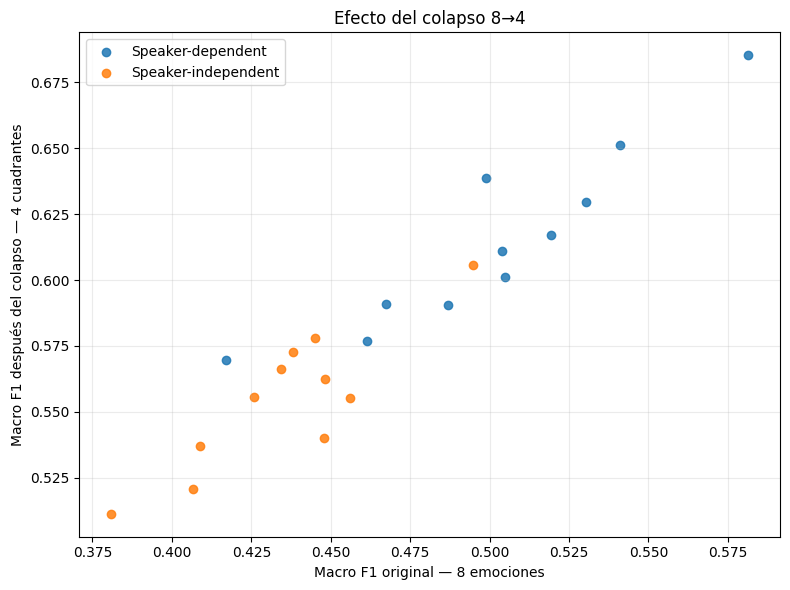

In [24]:
if not cv_results.empty:
    plot_8_to_4_tradeoff(cv_results)

Para `emotion_original_eval_quadrant`, el eje horizontal conserva la dificultad original de ocho clases y el eje vertical muestra el resultado después de colapsar las predicciones a cuadrantes.

## 8. Feature importance sobre eGeMAPSv02

In [25]:
if RUN_FEATURE_IMPORTANCE:
    importance_output = run_feature_importance_grid(
        egemaps=representations["egemaps"],
        metadata=metadata,
        splits=splits,
        model_configs=cfg.models,
        seed=cfg.seed,
        protocols=PROTOCOLS,
        targets=TARGETS,
        top_k=cfg.refinements.feature_importance.top_k,
        permutation_repeats=cfg.refinements.feature_importance.permutation_repeats,
        n_folds=cfg.splits.cv_folds,
    )
    feature_selection = upsert_feature_selection(
        feature_selection,
        importance_output["feature_results"],
    )
    save_feature_selection(feature_selection, feature_selection_path)
    print(f"Importancias guardadas en {feature_selection_path}")

importance_rows = (
    feature_selection.query("method != 'rfecv'")
    if not feature_selection.empty
    else pd.DataFrame()
)
importance_summary = summarize_feature_importance(importance_rows)

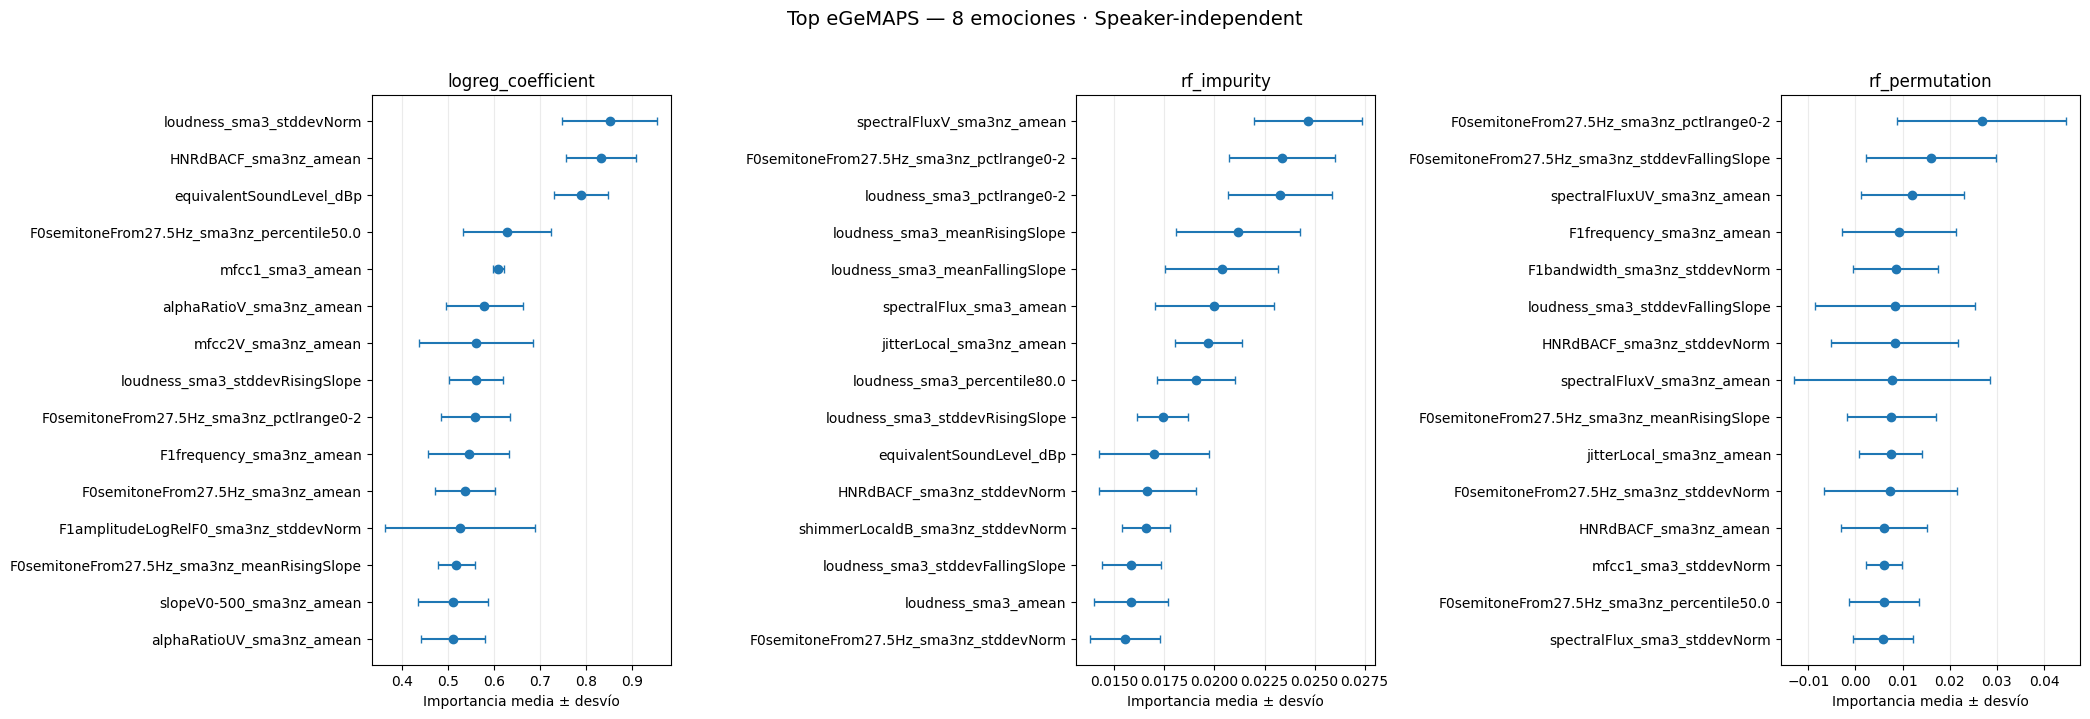

In [26]:
IMPORTANCE_PROTOCOL = "speaker_independent"
IMPORTANCE_TARGET = "emotion_original"
IMPORTANCE_TOP_K = 15

importance_plot = (
    importance_summary
    .query(
        "protocol == @IMPORTANCE_PROTOCOL and "
        "target == @IMPORTANCE_TARGET"
    )
    .copy()
    if not importance_summary.empty
    else pd.DataFrame()
)

if importance_plot.empty:
    print("Sin importancias calculadas.")
else:
    methods = list(importance_plot["method"].drop_duplicates())
    fig, axes = plt.subplots(
        1,
        len(methods),
        figsize=(7 * len(methods), 7),
        squeeze=False,
    )

    for ax, method in zip(axes.ravel(), methods):
        method_data = (
            importance_plot.query("method == @method")
            .sort_values("importance_mean", ascending=False)
            .head(IMPORTANCE_TOP_K)
            .sort_values("importance_mean")
        )
        ax.errorbar(
            method_data["importance_mean"],
            method_data["feature"],
            xerr=method_data["importance_std"],
            fmt="o",
            capsize=3,
        )
        ax.set_title(method)
        ax.set_xlabel("Importancia media ± desvío")
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle(
        f"Top eGeMAPS — {TARGET_LABELS[IMPORTANCE_TARGET]} · "
        f"{PROTOCOL_LABELS[IMPORTANCE_PROTOCOL]}",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

## 9. RFECV nested

RFECV se ajusta exclusivamente dentro de cada outer train. Las figuras muestran:

- cuántas features conserva por fold;
- estabilidad de selección;
- rendimiento respecto del número de features.

In [27]:
if RUN_RFECV:
    rfecv_output = run_rfecv_grid(
        egemaps=representations["egemaps"],
        metadata=metadata,
        splits=splits,
        logistic_regression_config=cfg.models.logistic_regression,
        seed=cfg.seed,
        protocols=PROTOCOLS,
        targets=TARGETS,
        inner_folds=cfg.refinements.rfecv.inner_folds,
        step=cfg.refinements.rfecv.step,
        min_features_to_select=cfg.refinements.rfecv.min_features_to_select,
        n_jobs=cfg.refinements.rfecv.n_jobs,
        n_folds=cfg.splits.cv_folds,
    )

    cv_results = upsert_cv_results(
        cv_results,
        rfecv_output["fold_results"],
    )
    save_cv_results(cv_results, cv_results_path)

    feature_selection = upsert_feature_selection(
        feature_selection,
        rfecv_output["feature_results"],
    )
    save_feature_selection(feature_selection, feature_selection_path)

rfecv_rows = (
    cv_results.query("refinement == 'rfecv'")
    if not cv_results.empty
    else pd.DataFrame()
)

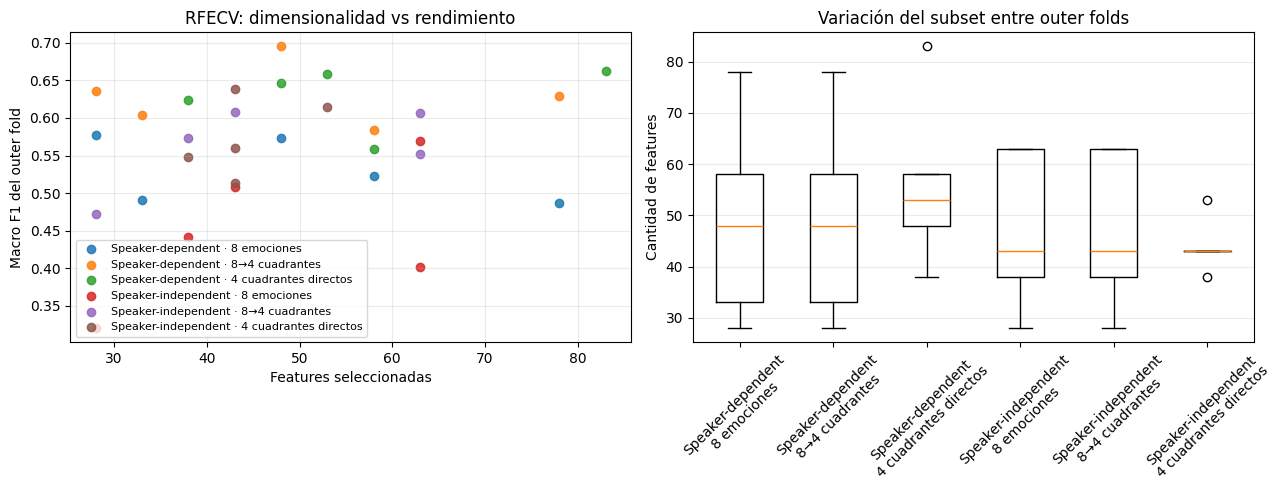

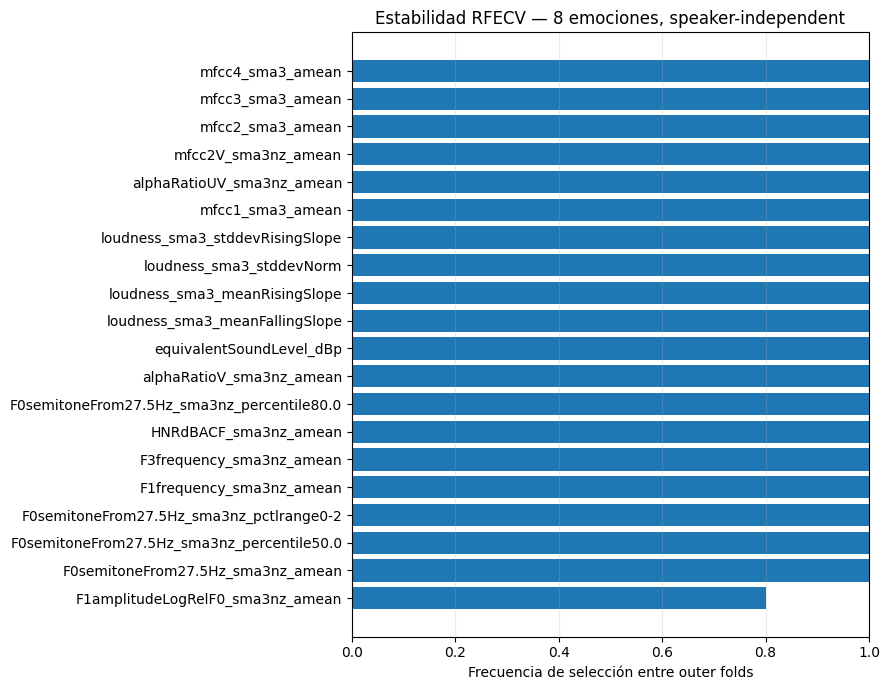

In [28]:
if rfecv_rows.empty:
    print("Sin resultados RFECV.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for (protocol, target), group in rfecv_rows.groupby(
        ["protocol", "target"],
        observed=True,
    ):
        label = (
            f"{PROTOCOL_LABELS.get(protocol, protocol)} · "
            f"{TARGET_LABELS.get(target, target)}"
        )
        axes[0].scatter(
            group["n_features"],
            group["macro_f1"],
            label=label,
            alpha=0.85,
        )

    axes[0].set_xlabel("Features seleccionadas")
    axes[0].set_ylabel("Macro F1 del outer fold")
    axes[0].set_title("RFECV: dimensionalidad vs rendimiento")
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    rfecv_counts = (
        rfecv_rows
        .groupby(["protocol", "target"], observed=True)["n_features"]
        .apply(list)
    )
    labels = [
        f"{PROTOCOL_LABELS.get(protocol, protocol)}\n{TARGET_LABELS.get(target, target)}"
        for protocol, target in rfecv_counts.index
    ]
    axes[1].boxplot(rfecv_counts.tolist(), tick_labels=labels)
    axes[1].set_ylabel("Cantidad de features")
    axes[1].set_title("Variación del subset entre outer folds")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    stability_plot = (
        feature_selection
        .query(
            "method == 'rfecv' and "
            "protocol == 'speaker_independent' and "
            "target == 'emotion_original'"
        )
        .groupby("feature", observed=True)
        .agg(
            selection_frequency=("selected", "mean"),
            rank_mean=("rank", "mean"),
        )
        .reset_index()
        .sort_values(
            ["selection_frequency", "rank_mean"],
            ascending=[False, True],
        )
        .head(20)
        .sort_values("selection_frequency")
    )

    if not stability_plot.empty:
        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh(
            stability_plot["feature"],
            stability_plot["selection_frequency"],
        )
        ax.set_xlim(0, 1)
        ax.set_xlabel("Frecuencia de selección entre outer folds")
        ax.set_title(
            "Estabilidad RFECV — 8 emociones, speaker-independent"
        )
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()

## 10. PCA dentro de outer CV

In [29]:
if RUN_PCA:
    pca_output = run_pca_grid(
        representations=representations,
        metadata=metadata,
        splits=splits,
        logistic_regression_config=cfg.models.logistic_regression,
        seed=cfg.seed,
        representation_names=REPRESENTATIONS,
        protocols=PROTOCOLS,
        targets=TARGETS,
        variance_thresholds=cfg.refinements.pca.variance_thresholds,
        n_folds=cfg.splits.cv_folds,
    )

    cv_results = upsert_cv_results(
        cv_results,
        pca_output["fold_results"],
    )
    save_cv_results(cv_results, cv_results_path)

pca_rows = (
    cv_results[
        cv_results["refinement"].astype(str).str.startswith("pca_")
    ]
    if not cv_results.empty
    else pd.DataFrame()
)

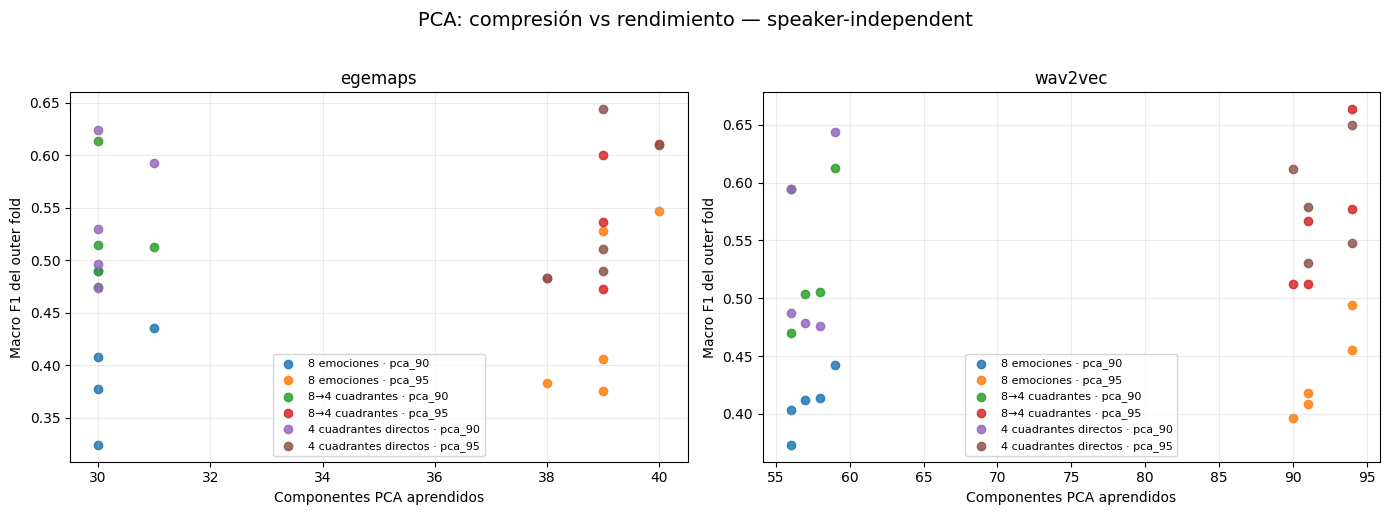

In [30]:
if pca_rows.empty:
    print("Sin resultados PCA.")
else:
    PCA_PROTOCOL = "speaker_independent"

    pca_plot = pca_rows.query("protocol == @PCA_PROTOCOL").copy()
    pca_plot["target_label"] = pca_plot["target"].map(TARGET_LABELS)

    fig, axes = plt.subplots(
        1,
        len(REPRESENTATIONS),
        figsize=(7 * len(REPRESENTATIONS), 5),
        squeeze=False,
    )

    for ax, representation in zip(axes.ravel(), REPRESENTATIONS):
        rep_data = pca_plot.query(
            "representation == @representation"
        )
        for (target, refinement), group in rep_data.groupby(
            ["target", "refinement"],
            observed=True,
        ):
            ax.scatter(
                group["pca_n_components"],
                group["macro_f1"],
                label=f"{TARGET_LABELS[target]} · {refinement}",
                alpha=0.85,
            )

        ax.set_xlabel("Componentes PCA aprendidos")
        ax.set_ylabel("Macro F1 del outer fold")
        ax.set_title(representation)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

    fig.suptitle(
        "PCA: compresión vs rendimiento — speaker-independent",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

## 11. Comparación visual baseline vs refinamientos

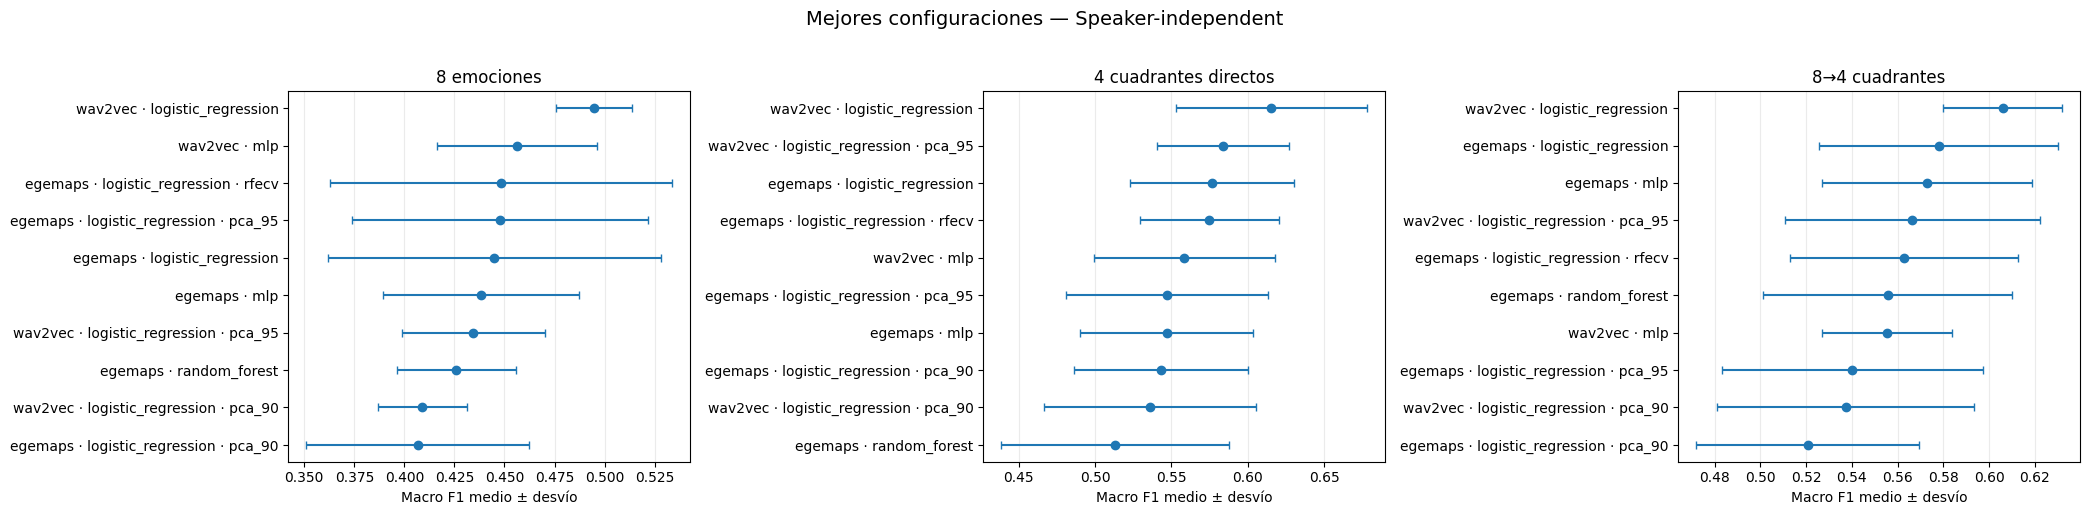

In [31]:
if not cv_results.empty:
    comparison = summarize_cv_results(cv_results)
    plot_top_configurations(
        comparison,
        protocol="speaker_independent",
        top_n=10,
    )

## 12. Matrices de confusión normalizadas

Se construyen a partir de predicciones *out-of-fold* de development:

1. una matriz para el mejor baseline de cada target;
2. una comparación controlada de Logistic Regression antes y después del mejor refinamiento compatible;
3. una matriz de diferencias `refinamiento − baseline`.

La matriz de diferencias debe leerse así:

- diagonal positiva: mejora del recall de esa clase;
- diagonal negativa: empeoramiento;
- valores fuera de diagonal: cambios en patrones de confusión.

La comparación controlada mantiene representación, modelo, target, protocolo y folds.

In [32]:
CONFUSION_PROTOCOL = "speaker_independent"
RUN_CONFUSION_MATRICES = True
REFINEMENT_TRACK_TARGET = "emotion_original"
OOF_CACHE_PATH = resolve_path("reports/oof_predictions_selected.csv")


def collect_oof_predictions(config_row):
    row = config_row.to_dict() if hasattr(config_row, "to_dict") else dict(config_row)

    representation_name = row["representation"]
    protocol = row["protocol"]
    target = row["target"]
    model = row["model"]
    refinement = str(row["refinement"])

    if refinement == "none":
        factory = make_model_factory(
            model_name=model,
            model_config=cfg.models[model],
            seed=cfg.seed,
        )
        output = run_cv(
            pipeline_factory=factory,
            representation=representations[representation_name],
            metadata=metadata,
            splits=splits,
            target_col=target,
            protocol=protocol,
            representation_name=representation_name,
            model_name=model,
            refinement="none",
            n_folds=cfg.splits.cv_folds,
        )

    elif refinement.startswith("pca_"):
        if model != "logistic_regression":
            raise ValueError(
                "PCA solo está definido para logistic_regression."
            )

        variance_threshold = float(refinement.split("_", maxsplit=1)[1]) / 100.0
        factory = partial(
            build_pca_linear_probe,
            logistic_regression_params=cfg.models.logistic_regression,
            seed=cfg.seed,
            variance_threshold=variance_threshold,
        )
        output = run_cv(
            pipeline_factory=factory,
            representation=representations[representation_name],
            metadata=metadata,
            splits=splits,
            target_col=target,
            protocol=protocol,
            representation_name=representation_name,
            model_name=model,
            refinement=refinement,
            n_folds=cfg.splits.cv_folds,
            fitted_metadata_fn=get_pca_fold_metadata,
        )

    elif refinement == "rfecv":
        if representation_name != "egemaps" or model != "logistic_regression":
            raise ValueError(
                "RFECV solo está definido para eGeMAPS + Logistic Regression."
            )

        output = run_nested_rfecv(
            representation=representations["egemaps"],
            metadata=metadata,
            splits=splits,
            target_col=target,
            protocol=protocol,
            logistic_regression_params=cfg.models.logistic_regression,
            seed=cfg.seed,
            inner_folds=cfg.refinements.rfecv.inner_folds,
            step=cfg.refinements.rfecv.step,
            min_features_to_select=cfg.refinements.rfecv.min_features_to_select,
            n_jobs=cfg.refinements.rfecv.n_jobs,
            n_folds=cfg.splits.cv_folds,
        )
    else:
        raise ValueError(f"Refinamiento no soportado: {refinement!r}")

    predictions = output["predictions"].copy()
    for column in EXPERIMENT_COLUMNS:
        predictions[column] = row[column]

    return predictions


def config_mask(frame, row):
    mask = pd.Series(True, index=frame.index)
    for column in EXPERIMENT_COLUMNS:
        mask &= frame[column].astype(str).eq(str(row[column]))
    return mask


def load_or_collect_oof(selected_configs):
    cached = (
        pd.read_csv(OOF_CACHE_PATH)
        if OOF_CACHE_PATH.exists()
        else pd.DataFrame()
    )
    collected = [cached] if not cached.empty else []

    for _, config_row in selected_configs.drop_duplicates(
        EXPERIMENT_COLUMNS
    ).iterrows():
        already_cached = (
            not cached.empty
            and config_mask(cached, config_row).any()
        )
        if already_cached:
            continue

        print(
            "Calculando OOF:",
            configuration_label(config_row),
            "|",
            TARGET_LABELS.get(config_row["target"], config_row["target"]),
        )
        collected.append(
            collect_oof_predictions(config_row)
        )

    if not collected:
        return pd.DataFrame()

    result = pd.concat(collected, ignore_index=True, sort=False)
    result = result.drop_duplicates(
        subset=EXPERIMENT_COLUMNS + ["file_id"],
        keep="last",
    )
    OOF_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    result.to_csv(OOF_CACHE_PATH, index=False)
    return result

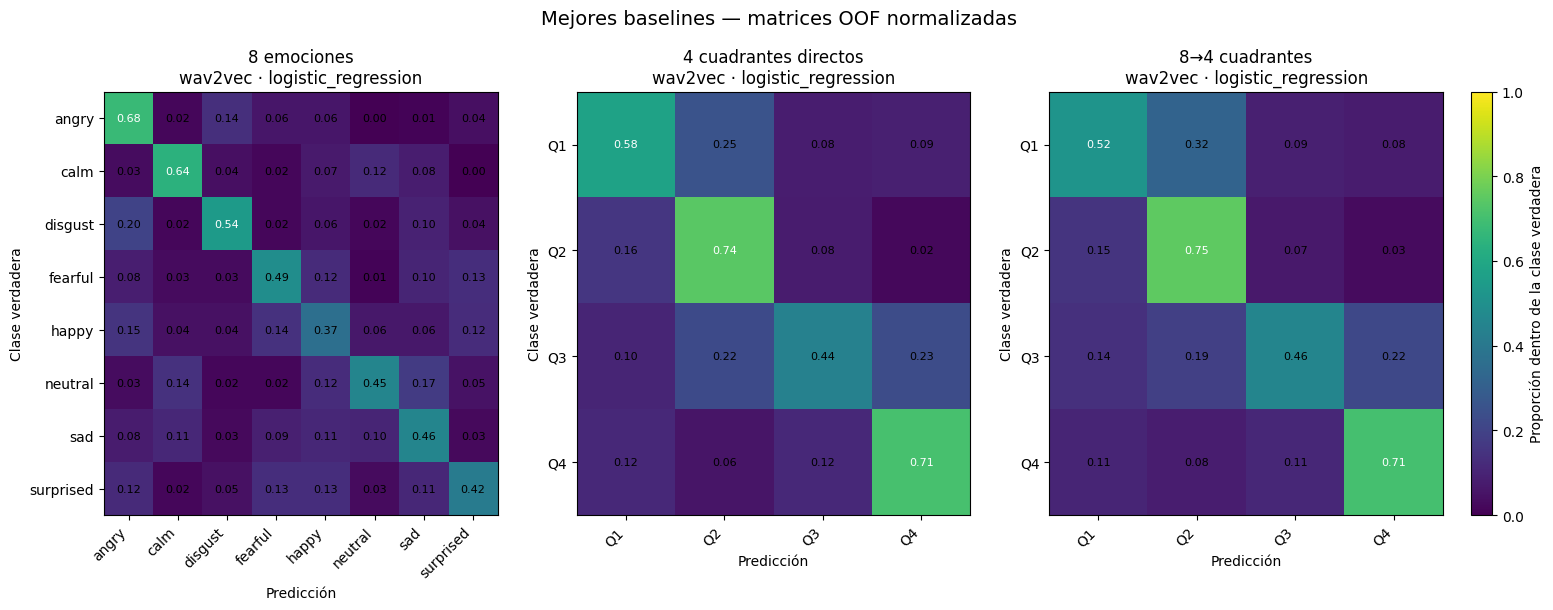

In [33]:
if summary.empty:
    print("No hay resultados para seleccionar matrices de confusión.")
elif not RUN_CONFUSION_MATRICES:
    print("Matrices desactivadas.")
else:
    baseline_summary = (
        summary
        .query(
            "protocol == @CONFUSION_PROTOCOL and "
            "refinement == 'none'"
        )
        .sort_values(
            ["target", "macro_f1_mean", "macro_f1_std"],
            ascending=[True, False, True],
        )
    )

    best_baselines = (
        baseline_summary
        .groupby("target", observed=True, group_keys=False)
        .head(1)
        .reset_index(drop=True)
    )

    oof_predictions = load_or_collect_oof(best_baselines)

    targets = [
        target
        for target in TARGETS
        if target in set(best_baselines["target"])
    ]
    fig, axes = plt.subplots(
        1,
        len(targets),
        figsize=(6 * len(targets), 5.5),
        squeeze=False,
    )

    for ax, target in zip(axes.ravel(), targets):
        config_row = best_baselines.query("target == @target").iloc[0]
        predictions = oof_predictions.loc[
            config_mask(oof_predictions, config_row)
        ]

        title = (
            f"{TARGET_LABELS[target]}\n"
            f"{configuration_label(config_row)}"
        )
        image, _, _ = plot_normalized_confusion(
            predictions,
            title=title,
            ax=ax,
        )

    fig.colorbar(
        image,
        ax=axes.ravel().tolist(),
        fraction=0.02,
        pad=0.02,
        label="Proporción dentro de la clase verdadera",
    )
    fig.suptitle(
        "Mejores baselines — matrices OOF normalizadas",
        y=1.03,
        fontsize=14,
    )
    plt.show()

Calculando OOF: egemaps · logistic_regression | 8 emociones
2026-06-23 13:35:05 | INFO     | src.experiments.cross_validation | === CV: egemaps_logistic_regression_emotion_original_speaker_independent_none ===
2026-06-23 13:35:05 | INFO     | src.evaluation.metrics | [Fold 0] macro_F1=0.3335 | BalAcc=0.3691 | UAR=0.3691 | Acc=0.3681
2026-06-23 13:35:05 | INFO     | src.evaluation.metrics | [Fold 1] macro_F1=0.3706 | BalAcc=0.3939 | UAR=0.3939 | Acc=0.4167
2026-06-23 13:35:05 | INFO     | src.evaluation.metrics | [Fold 2] macro_F1=0.4513 | BalAcc=0.4490 | UAR=0.4490 | Acc=0.4688
2026-06-23 13:35:05 | INFO     | src.evaluation.metrics | [Fold 3] macro_F1=0.5524 | BalAcc=0.5702 | UAR=0.5702 | Acc=0.5556
2026-06-23 13:35:05 | INFO     | src.evaluation.metrics | [Fold 4] macro_F1=0.5169 | BalAcc=0.5177 | UAR=0.5177 | Acc=0.5260
2026-06-23 13:35:05 | INFO     | src.experiments.cross_validation | === egemaps_logistic_regression_emotion_original_speaker_independent_none — macro_F1 0.4449 ± 0.0

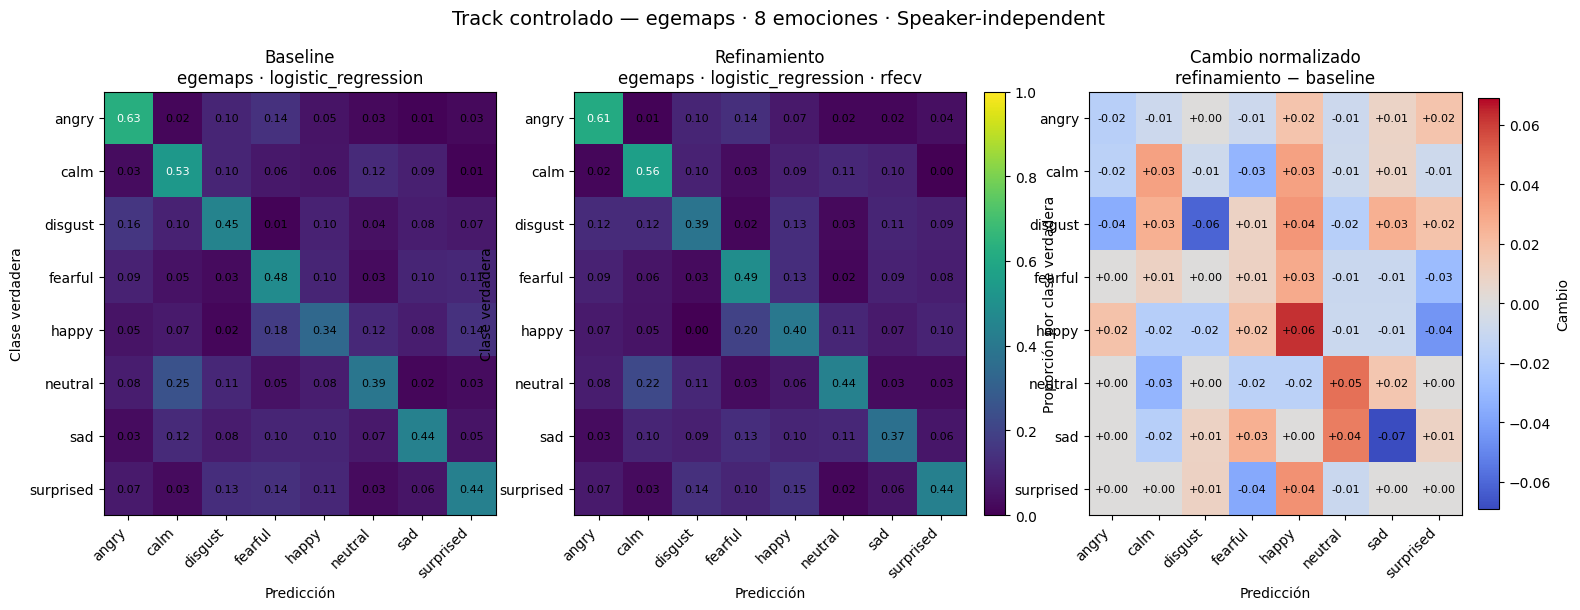

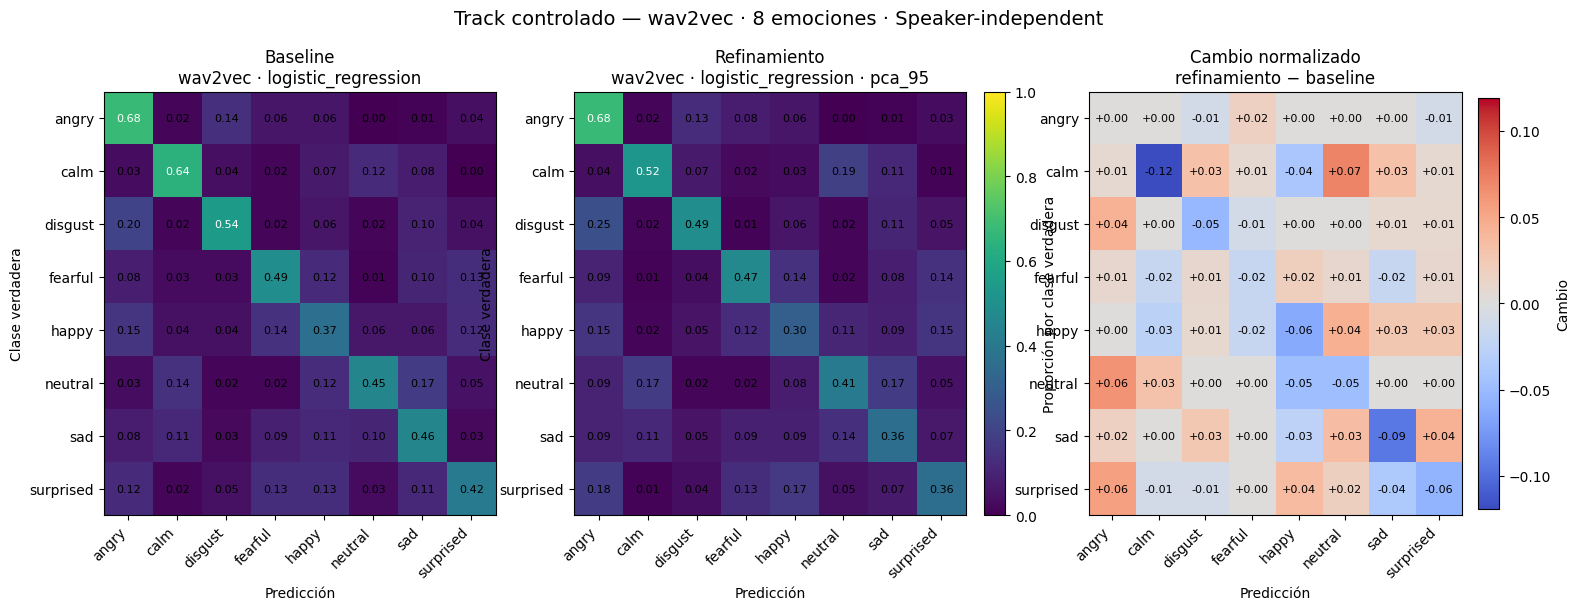

In [34]:
if not summary.empty and RUN_CONFUSION_MATRICES:
    controlled = summary.query(
        "protocol == @CONFUSION_PROTOCOL and "
        "target == @REFINEMENT_TRACK_TARGET and "
        "model == 'logistic_regression'"
    ).copy()

    tracks = []

    for representation_name in REPRESENTATIONS:
        family = controlled.query(
            "representation == @representation_name"
        )

        baseline = family.query("refinement == 'none'")
        refined = family.query("refinement != 'none'")

        if baseline.empty or refined.empty:
            continue

        baseline_row = baseline.sort_values(
            ["macro_f1_mean", "macro_f1_std"],
            ascending=[False, True],
        ).iloc[0]
        refined_row = refined.sort_values(
            ["macro_f1_mean", "macro_f1_std"],
            ascending=[False, True],
        ).iloc[0]

        tracks.extend([baseline_row, refined_row])

    track_configs = pd.DataFrame(tracks)

    if track_configs.empty:
        print("No hay pares baseline/refinamiento comparables.")
    else:
        oof_predictions = load_or_collect_oof(track_configs)

        for representation_name in track_configs["representation"].unique():
            family = track_configs.query(
                "representation == @representation_name"
            )

            baseline_row = family.query("refinement == 'none'").iloc[0]
            refined_row = family.query("refinement != 'none'").iloc[0]

            baseline_predictions = oof_predictions.loc[
                config_mask(oof_predictions, baseline_row)
            ]
            refined_predictions = oof_predictions.loc[
                config_mask(oof_predictions, refined_row)
            ]

            fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

            image, _, labels = plot_normalized_confusion(
                baseline_predictions,
                title=f"Baseline\n{configuration_label(baseline_row)}",
                ax=axes[0],
            )
            plot_normalized_confusion(
                refined_predictions,
                title=f"Refinamiento\n{configuration_label(refined_row)}",
                labels=labels,
                ax=axes[1],
            )
            delta_image, _ = plot_confusion_delta(
                baseline_predictions,
                refined_predictions,
                title="Cambio normalizado\nrefinamiento − baseline",
                labels=labels,
                ax=axes[2],
            )

            fig.colorbar(
                image,
                ax=axes[:2].tolist(),
                fraction=0.025,
                pad=0.02,
                label="Proporción por clase verdadera",
            )
            fig.colorbar(
                delta_image,
                ax=axes[2],
                fraction=0.05,
                pad=0.04,
                label="Cambio",
            )
            fig.suptitle(
                f"Track controlado — {representation_name} · "
                f"{TARGET_LABELS[REFINEMENT_TRACK_TARGET]} · "
                f"{PROTOCOL_LABELS[CONFUSION_PROTOCOL]}",
                y=1.03,
                fontsize=14,
            )
            plt.show()

## 13. Cierre de Sprint 3

Antes de abrir los tests finales se debe:

1. verificar que cada configuración tenga cinco folds;
2. revisar las matrices de confusión de los mejores baselines;
3. comparar los cambios por clase en PCA y RFECV;
4. aplicar la tolerancia práctica de macro F1;
5. congelar la configuración primaria y el baseline de referencia en `reports/model_selection.md`.

El autoencoder queda diferido salvo que PCA o RFECV aporten evidencia clara que justifique una reducción no lineal.